In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

print('Ready!')

Ready!


In [2]:
# Load all saved results from results/metrics/
results = []

for filename in os.listdir('results/metrics'):
    if filename.endswith('.json'):
        with open(f'results/metrics/{filename}') as f:
            results.append(json.load(f))

# Convert to DataFrame — удобно для анализа и графиков
df_results = pd.DataFrame(results)
print(df_results[['dataset', 'model', 'accuracy', 'f1', 'roc_auc']])

   dataset                model  accuracy      f1  roc_auc
0    cssrs  logistic_regression    0.5900  0.4379   0.7850
1    cssrs        random_forest    0.6700  0.6431   0.7288
2    cssrs                  svm    0.7000  0.6686      NaN
3   reddit  logistic_regression    0.9414  0.9414   0.9841
4   reddit        random_forest    0.9082  0.9082   0.9680
5   reddit                  svm    0.9396  0.9396      NaN
6  twitter  logistic_regression    0.8992  0.8976   0.9669
7  twitter        random_forest    0.9412  0.9405   0.9773
8  twitter                  svm    0.9216  0.9220      NaN


dataset               cssrs  reddit  twitter
model                                       
logistic_regression  0.4379  0.9414   0.8976
random_forest        0.6431  0.9082   0.9405
svm                  0.6686  0.9396   0.9220


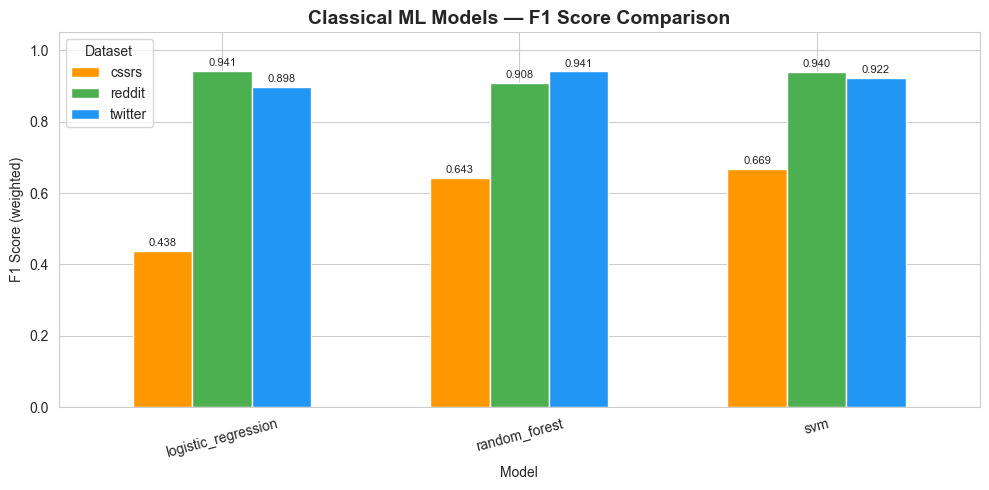

Saved!


In [3]:
# Pivot table — строки = модели, колонки = датасеты
# Это удобный формат для построения grouped bar chart
pivot = df_results.pivot(index='model', columns='dataset', values='f1')
print(pivot)

# Grouped bar chart
ax = pivot.plot(kind='bar', figsize=(10, 5), 
                color=['#FF9800', '#4CAF50', '#2196F3'],
                edgecolor='white', width=0.6)

ax.set_title('Classical ML Models — F1 Score Comparison', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (weighted)')
ax.set_ylim(0, 1.05)
ax.legend(title='Dataset')
ax.tick_params(axis='x', rotation=15)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/ml_f1_comparison.png', dpi=150)
plt.show()
print('Saved!')

💡 Что такое pivot table? Это способ реорганизовать таблицу — строки становятся колонками и наоборот. Здесь мы делаем так чтобы каждая модель была строкой, а каждый датасет — колонкой. Это идеальный формат для grouped bar chart.

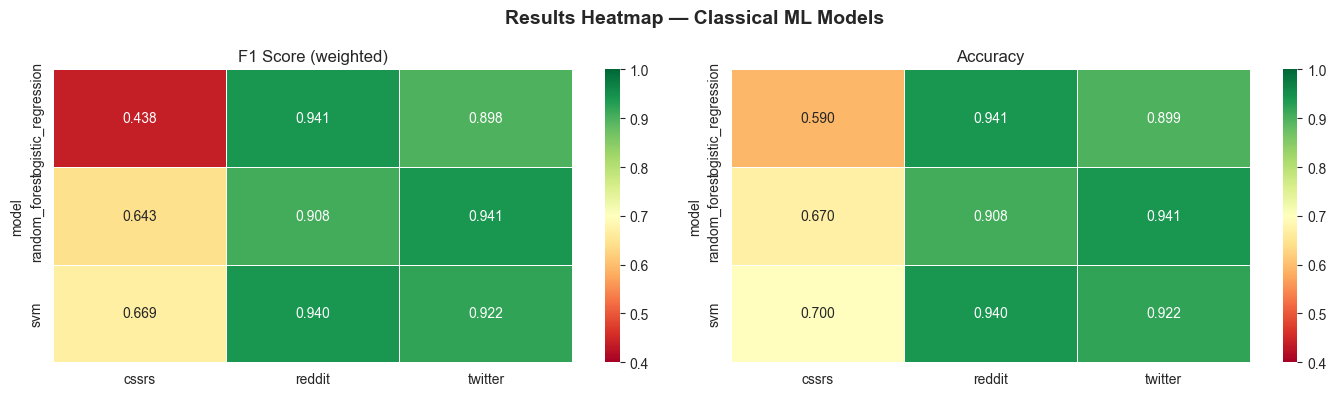

Saved!


In [4]:
# Heatmap — показывает все результаты в одной картинке
# Тёмный цвет = высокий F1, светлый = низкий
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Results Heatmap — Classical ML Models', 
             fontsize=14, fontweight='bold')

# F1 heatmap
pivot_f1 = df_results.pivot(index='model', columns='dataset', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=axes[0], linewidths=0.5)
axes[0].set_title('F1 Score (weighted)')
axes[0].set_xlabel('')

# Accuracy heatmap  
pivot_acc = df_results.pivot(index='model', columns='dataset', values='accuracy')
sns.heatmap(pivot_acc, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=1.0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('results/plots/ml_heatmap.png', dpi=150)
plt.show()
print('Saved!')

💡 Почему тепловая карта полезна? Она позволяет одним взглядом увидеть паттерны. Например сразу видно что C-SSRS самый сложный датасет (вся колонка красная), а Reddit и Twitter модели справляются хорошо (зелёные).


In [5]:
# Final summary table 
print('=' * 65)
print('CLASSICAL ML RESULTS — FULL COMPARISON TABLE')
print('=' * 65)

# Sort by dataset and F1
df_sorted = df_results.sort_values(['dataset', 'f1'], ascending=[True, False])

# Format nicely
for dataset in ['twitter', 'reddit', 'cssrs']:
    subset = df_sorted[df_sorted['dataset'] == dataset]
    print(f'\n📊 Dataset: {dataset.upper()}')
    print(f'  {"Model":<25} {"Accuracy":>10} {"F1":>10} {"ROC-AUC":>10}')
    print(f'  {"-"*55}')
    for _, row in subset.iterrows():
        roc = f'{row["roc_auc"]:.4f}' if pd.notna(row['roc_auc']) else 'N/A'
        print(f'  {row["model"]:<25} {row["accuracy"]:>10.4f} {row["f1"]:>10.4f} {roc:>10}')

print('\n' + '=' * 65)
print('KEY FINDINGS')
print('=' * 65)

# Best model per dataset
for dataset in ['twitter', 'reddit', 'cssrs']:
    subset = df_results[df_results['dataset'] == dataset]
    best = subset.loc[subset['f1'].idxmax()]
    print(f'  Best on {dataset:<10}: {best["model"]:<25} F1={best["f1"]:.4f}')

CLASSICAL ML RESULTS — FULL COMPARISON TABLE

📊 Dataset: TWITTER
  Model                       Accuracy         F1    ROC-AUC
  -------------------------------------------------------
  random_forest                 0.9412     0.9405     0.9773
  svm                           0.9216     0.9220        N/A
  logistic_regression           0.8992     0.8976     0.9669

📊 Dataset: REDDIT
  Model                       Accuracy         F1    ROC-AUC
  -------------------------------------------------------
  logistic_regression           0.9414     0.9414     0.9841
  svm                           0.9396     0.9396        N/A
  random_forest                 0.9082     0.9082     0.9680

📊 Dataset: CSSRS
  Model                       Accuracy         F1    ROC-AUC
  -------------------------------------------------------
  svm                           0.7000     0.6686        N/A
  random_forest                 0.6700     0.6431     0.7288
  logistic_regression           0.5900     0.4379    

# Key findings markdown summary

CLASSICAL ML MODELS — KEY FINDINGS
====================================

1. BEST MODEL PER DATASET:
   - Twitter : Random Forest  (F1 = 0.9405)
   - Reddit  : Logistic Regression (F1 = 0.9414)  
   - C-SSRS  : SVM (F1 = 0.6686)

2. CROSS-DATASET OBSERVATIONS:
   - No single model wins across all datasets
   - Twitter and Reddit are much easier than C-SSRS
   - C-SSRS results drop significantly (best F1 = 0.67 vs 0.94)

3. MODEL BEHAVIOUR:
   - Logistic Regression: surprisingly strong on large balanced Reddit dataset
   - SVM: most consistent — best or close to best on all three datasets
   - Random Forest: best on Twitter, worst on Reddit

4. C-SSRS CHALLENGE:
   - Logistic Regression completely fails on class 0 (F1 = 0.44)
   - Only 500 samples — not enough for TF-IDF to generalise
   - SVM most robust to class imbalance here

5. IMPLICATION FOR NEXT STEPS:
   - Deep Learning (LSTM/BiLSTM) may help on C-SSRS (longer context)
   - BERT likely to improve C-SSRS most — contextual understanding needed
